In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.style.use('ggplot')

# Statistical Inference of a Single Population - Proportions

In the previous notebook, we saw various ways to perform statistical inference of  continuous random variables. This time we will apply the same logic to the proportions.

## Confidence Intervals with Analytical Methods


**Example**

Let's say we have a sample consisting of a sequence of Bernoulli trials. We want to make inferences about the population proportion. In this case, if success (1) and failure (0) conditions both have at least 10 data points (the more the better), then we can assume that the distribution is *approximately* normal. We can use the following terms:

Standard error:

$SE = \sqrt{\frac{{\hat{p} \times (1 - \hat{p})}}{n}}$ where $\hat{p}$ refers to the sample proportion.

Error margin:

$E = z^{\star} \times \sqrt{\frac{{\hat{p} \times (1 - \hat{p})}}{n}}$

where $z^{\star}$ refers to the desired confidence level.

Example:

$CI_{95}$: $\quad$ $z^{\star} = 1.96$

In [2]:
np.random.seed(42)
population = stats.bernoulli.rvs(p = 0.5,size = 1000, random_state = 42)
sample = np.random.choice(population,size = 50)

np.unique(sample,return_counts = True)

(array([0, 1]), array([24, 26]))

Perfect! Since we have more than 10 data points for each group we can assume that the distribution is approximately normal.

In [3]:
z = 1.96

sample_proportion = sample.mean()
se = np.sqrt(sample_proportion * (1 - sample_proportion) / len(sample))
ci = (sample_proportion - z * se, sample_proportion + z * se)
ci

(np.float64(0.3815179896159794), np.float64(0.6584820103840207))

## Bootstrap Sampling on Proportions

Alternatively, we can use bootstrapping to get similar results. Again the best thing about bootstrapping is that it does not require making any distribution assumptions.

ConfidenceInterval(low=np.float64(0.38), high=np.float64(0.66))


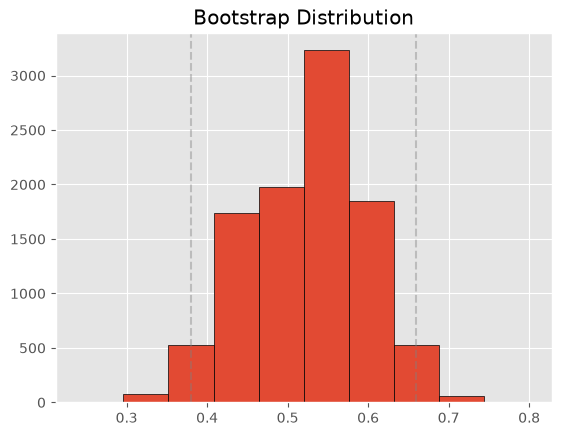

In [4]:
boots = stats.bootstrap((sample,),statistic = np.mean,random_state = 42)
print(boots.confidence_interval)
plt.figure()
plt.hist(boots.bootstrap_distribution,edgecolor = 'black', bins = 10)
plt.axvline(x = boots.confidence_interval.low, color = 'grey', alpha = 0.4,linestyle = "--")
plt.axvline(x = boots.confidence_interval.high, color = 'grey', alpha = 0.4,linestyle = "--")
plt.title("Bootstrap Distribution")
plt.show()